# Phase 1: Data Harmonization

In [42]:
import pandas as pd
import numpy as np

### Standardize the column names in each year
We rename different column names from each year into a common set., so now all the datasets follow single, uniform structure

In [43]:
SCHEMA = {
    2018: {
        "crime_head"       : "Crime Head (Col.3)",
        "category"         : "Category (Col.2)",          # only 2018 has this
        "cases_pending_prev": "Cases Pending Investigation from Previous Year (Col.4)",
        "cases_reported"   : "Cases Reported during the year (Col.5)",
        "cases_reopened"   : "Cases Reopened for Investigation (Col.6)",
        "total_for_inv"    : "Total Cases for Investigation (Col.7=Col.4+ Col.5+ Col.6)",
        "not_investigated" : "Cases Not Investigated under 157_1_b CRPC (Col.8)",
        "transferred"      : "Cases Transferred to other State or Agency (Col.9)",
        "withdrawn"        : "Cases Withdrawn by the Govt during Investigation (Col.10)",
        "fr_non_cognizable": "Final Report - Cases Ended as FR Non Cognizable (Col.11)",
        "fr_false"         : "Final Report - Cases Ended as Final Report False (Col.12)",
        "fr_mistake"       : "Final Report - Cases Ended as Mistake of Fact or of Law or Civil Dispute (Col.13)",
        "fr_insufficient"  : "Final Report - Cases True but Insufficient Evidence or Untraced or No Clue (Col.14)",
        "fr_abated"        : "Final Report - Cases Abated during Investigation (Col.15)",
        "fr_total"         : "Final Report - Total (Col.16=Col.11+ Col.12+ Col.13+ Col.14+ Col.15)",
        "cs_from_prev"     : "Chargesheets Submitted - Cases Chargsheeted Out of Cases from Previous Year (Col.17)",
        "cs_from_year"     : "Chargesheets Submitted - Cases Chargesheeted Out of Cases during the Year (Col.18)",
        "cs_total"         : "Chargesheets Submitted - Cases Chargesheeted (Col.19=Col.17+ Col.18)",
        "total_disposed"   : "Total Cases Disposed Off by Police (Col.20=Col.8+ Col.9+ Col.16+ Col.19)",
        "quashed"          : "Cases Quashed at Investigation Stage (Col.21)",
        "stayed"           : "Cases Stayed at Investigation Stage (Col.22)",
        "cases_pending_end": "Cases Pending Investigation at End of the Year (Col.23=Col.7- Col.10- Col.20- Col.21)",
        "chargesheeting_rate": "Chargesheeting Rate (Col.24=Col.19/ Col.20) *100",
        "pendency_pct"     : "Pendency Percentage (Col.25=Col.23/ Col.7) *100",
    },
    2019: {
        "crime_head"       : "Crime Head",
        "cases_pending_prev": "Cases Pending Investigation from Previous Year",
        "cases_reported"   : "Cases Reported during the year",
        "cases_reopened"   : "Cases Reopened for Investigation",
        "total_for_inv"    : "Total Cases for Investigation (Col.3+ Col.4+ Col.5)",
        "not_investigated" : "Cases Not Investigated Under 157_1_b CRPC",
        "transferred"      : "Cases Transferred to other State or Agency",
        "withdrawn"        : "Cases Withdrawn by the Govt during investigation",
        "fr_non_cognizable": "Final Report - Cases Ended as FR Non Cognizable",
        "fr_false"         : "Final Report - Cases Ended as Final Report False",
        "fr_mistake"       : "Final Report - Cases Ended as Mistake of Fact or of Law or Civil Dispute",
        "fr_insufficient"  : "Final Report - Cases True but Insufficient Evidence or Untraced or No Clue",
        "fr_abated"        : "Final Report - Cases Abated during Investigation",
        "fr_total"         : "Final Report - Total (Col.10+ Col.11+ Col.12+ Col.13+ Col.14)",
        "cs_from_prev"     : "Chargesheets submitted - Cases Chargesheeted Out of Cases from Previous Year",
        "cs_from_year"     : "Chargesheets submitted - Cases Chargesheeted Out of Cases during the Year",
        "cs_total"         : "Chargesheets submitted - Cases Chargesheeted (Col.16+ Col.17)",
        "total_disposed"   : "Total Cases Disposed Off by Police (Col.7+ Col.8+ Col.15+ Col.18)",
        "quashed"          : "Cases Quashed at Investigation Stage",
        "stayed"           : "Cases Stayed at Investigation Stage",
        "cases_pending_end": "Cases Pending Investigation at End of the Year (Col.6- Col.9- Col.19- Col.20)",
        "chargesheeting_rate": "Charge-Sheeting Rate (Col.18/ Col.19) *100",
        "pendency_pct"     : "Pendency Percentage (Col.22/ Col.6) *100",
    },
    2020: {
        "crime_head"       : "Crime Head (Col. 2)",
        "cases_pending_prev": "Cases Pending Investigation from Previous Year - (Col. 3)",
        "cases_reported"   : "Cases Reported during the year - (Col. 4)",
        "cases_reopened"   : "Cases Reopened for Investigation - (Col. 5)",
        "total_for_inv"    : "Total Cases for Investi-gation (Col.3+ Col.4+ Col.5) - (Col. 6)",
        "not_investigated" : "Cases Not Investigated Under 157_1_b CRPC - (Col. 7)",
        "transferred"      : "Cases Transferred to Other State or Agency - (Col. 8)",
        "withdrawn"        : "Cases Withdrawn by the Govt during Investigation - (Col. 9)",
        "fr_non_cognizable": "Final Report - Cases Ended as FR Non Cognizable - (Col. 10)",
        "fr_false"         : "Final Report - Cases Ended as Final Report False - (Col. 11)",
        "fr_mistake"       : "Final Report - Cases Ended as Mistake of Fact or of law or Civil Dispute - (Col. 12)",
        "fr_insufficient"  : "Final Report - Cases True but Insufficient Evidence or Untraced or No Clue - (Col. 13)",
        "fr_abated"        : "Final Report - Cases Abated during Investigation - (Col. 14)",
        "fr_total"         : "Final Report - Total (Col.10+ Col.11+ Col.12+ Col13+ Col.14) - (Col. 15)",
        "cs_from_prev"     : "Charge Sheets Submitted - Cases Charge Sheeted Out of cases frm prv. Year - (Col. 16)",
        "cs_from_year"     : "Charge Sheets Submitted - Cases Chargesheeted Out of Cases during the year - (Col. 17)",
        "cs_total"         : "Charge Sheets Submitted - Cases Chargesheeted (Col.16+ Col.17) - (Col. 18)",
        "total_disposed"   : "Total Cases Disposed Off by Police (Col.7+8+15+18) - (Col. 19)",
        "quashed"          : "Cases Quashed at Investigation Stage - (Col. 20)",
        "stayed"           : "Cases Stayed at Investigation Stage - (Col. 21)",
        "cases_pending_end": "Cases Pending Invsgn.at end of the year (Cols. 6-9-19-20) - (Col. 22)",
        "chargesheeting_rate": "Chargesheeting Rate (Col.18/19*100) - (Col. 23)",
        "pendency_pct"     : "Pendency Percentage (Col.22/6*100) - (Col. 24)",
    },
    2021: {
        "crime_head"       : "Crime Head Col. (2)",
        "cases_pending_prev": "Cases Pending Investigation from Previous Year - Col. (3)",
        "cases_reported"   : "Cases Reported during the year - Col. (4)",
        "cases_reopened"   : "Cases Reopened for Investigation - Col. (5)",
        "total_for_inv"    : "Total Cases for Investigation (Col.3+Col.4+Col.5) - Col. (6)",
        "not_investigated" : "Cases Not Investigated Under 157_1_b CRPC - Col. (7)",
        "transferred"      : "Cases Transferred to Other State or Agency - Col. (8)",
        "withdrawn"        : "Cases Withdrawn by the Govt during Investigation - Col. (9)",
        "fr_non_cognizable": "Final Report - Cases Ended as FR Non Cognizable - Col. (10)",
        "fr_false"         : "Final Report - Cases Ended as Final Report False - Col. (11)",
        "fr_mistake"       : "Final Report - Cases Ended as Mistake of Fact or of law or Civil Dispute - Col. (12)",
        "fr_insufficient"  : "Final Report - Cases True but Insufficient Evidence or Untraced or No Clue - Col. (13)",
        "fr_abated"        : "Final Report - Cases Abated during Investigation - Col. (14)",
        "fr_total"         : "Final Report - Total (Col.10+Col.11+Col.12+Col13+Col.14) - Col. (15)",
        "cs_from_prev"     : "Charge Sheets Submitted - Cases ChargeSheeted Out of cases From Prev. Year - Col. (16)",
        "cs_from_year"     : "Charge Sheets Submitted - Cases Charge sheeted Out of Cases during the year - Col. (17)",
        "cs_total"         : "Charge Sheets Submitted - Cases Charge sheeted (Col.16+Col.17) - Col. (18)",
        "total_disposed"   : "Total Cases Disposed Off by Police (Col.7+8+15+18) - Col. (19)",
        "quashed"          : "Cases Quashed at Investigation Stage - Col. (20)",
        "stayed"           : "Cases Stayed at Investigation Stage - Col. (21)",
        "cases_pending_end": "Cases Pending Invsgn.at end of the year (Col.6-9-19-20) - Col. (22)",
        "chargesheeting_rate": "Chargesheeting Rate (Col.18/19*100) - Col. (23)",
        "pendency_pct"     : "Pendency Percentage (Col.22/6*100) - Col. (24)",
    },
}

In [44]:
#These are the list of aggregate/ summary rows that we need to remove
AGGREGATE_HEADS = {
    # exact lowercased strings after strip
    "total cognizable ipc crimes",
    "other ipc crimes",
    "miscellaneous ipc crimes (total)",
    "miscellaneous ipc crimes(total)",
    "other ipc crimes",
    "vigilants",
    
    # sub-total rollup rows (2018 has these as "-Total" variants)
    "offences against the state (total)",
    "offences against property (total)",
    "offences relating to documents & property marks (total)",
    "offences against public tranquillity (total)",
    "offences affecting the human body (total)",
}

In [45]:
# Read 2018 to extract crime_head -> category mapping
df18_raw = pd.read_csv("Datasets/Crime Head-wise Police Disposal of IPC Crime Cases during 2018.csv")
cat_col = "Category (Col.2)"
ch_col  = "Crime Head (Col.3)"

In [46]:
df18_raw["_norm"] = df18_raw[ch_col].str.strip().str.lower()\
                        .str.replace(r'\s*-\s*total\s*$', '', regex=True).str.strip()
df18_raw["_cat"]  = df18_raw[cat_col].ffill()   # category is only on parent rows

In [47]:
CATEGORY_MAP = dict(zip(df18_raw["_norm"], df18_raw["_cat"]))
# Clean up aggregates from the map
for k in list(CATEGORY_MAP.keys()):
    if k in AGGREGATE_HEADS:
        del CATEGORY_MAP[k]

print(f"Category map built: {len(CATEGORY_MAP)} entries")

Category map built: 129 entries


### Merging all years into One Dataset

In [48]:
# Load, normalise and stack all 4 years

LOGICAL_COLS = [c for c in SCHEMA[2018].keys() if c != "category"]

yearly_frames = []

for year in [2018, 2019, 2020, 2021]:
    raw = pd.read_csv(f"Datasets/Crime Head-wise Police Disposal of IPC Crime Cases during {year}.csv")
    schema = SCHEMA[year]

    # Select and rename to logical names
    cols = {}
    for k, v in schema.items():
        if k != "category":
            cols[k] = v
    
    selected_columns = list(cols.values())
    df_y = raw[selected_columns]
    
    rename_map = {}
    for k, v in cols.items():
        rename_map[v] = k
    
    df_y = df_y.rename(columns=rename_map).copy()

    # Normalise crime_head: strip, lowercase, remove trailing "- total"
    df_y["crime_head_norm"] = (
        df_y["crime_head"]
        .str.strip()
        .str.lower()
        .str.replace(r'\s*-\s*total\s*$', '', regex=True)
        .str.strip()
    )

    # Drop aggregate rows
    df_y = df_y[~df_y["crime_head_norm"].isin(AGGREGATE_HEADS)].copy()

    # Drop sub-category rows that are breakdowns of parent rows
    # (e.g. "hit and run", "rail accidents" are sub-rows of "causing death by negligence")

    df_y["year"] = year
    yearly_frames.append(df_y)
    print(f"{year}: {len(df_y)} crime heads after dropping aggregates")

2018: 134 crime heads after dropping aggregates
2019: 134 crime heads after dropping aggregates
2020: 135 crime heads after dropping aggregates
2021: 135 crime heads after dropping aggregates


In [49]:
# Filter to common core (128 crime heads in all 4 years)
sets = [set(f["crime_head_norm"]) for f in yearly_frames]
common_heads = sets[0]
for s in sets[1:]:
    common_heads = common_heads & s
common_heads = common_heads - AGGREGATE_HEADS

print(f"\nCommon crime heads across all 4 years: {len(common_heads)}")

filtered_frames = []
for df_y in yearly_frames:
    df_filtered = df_y[df_y["crime_head_norm"].isin(common_heads)].copy()
    filtered_frames.append(df_filtered)
    print(f"  {df_y['year'].iloc[0]}: {len(df_filtered)} rows kept")

master_df = pd.concat(filtered_frames, ignore_index=True)


Common crime heads across all 4 years: 125
  2018: 130 rows kept
  2019: 130 rows kept
  2020: 130 rows kept
  2021: 129 rows kept


In [50]:
# Attach category, ensure numeric types, handle 1 NaN
master_df["category"] = master_df["crime_head_norm"].map(CATEGORY_MAP)

# Fill any unmapped categories as "Other"
master_df["category"] = master_df["category"].fillna("Other IPC Crimes")

### Converting Columns to Numeric

In [51]:
# Ensure all pipeline columns are numeric
pipeline_cols = [
    "cases_pending_prev", "cases_reported", "cases_reopened",
    "total_for_inv", "not_investigated", "transferred", "withdrawn",
    "fr_non_cognizable", "fr_false", "fr_mistake", "fr_insufficient",
    "fr_abated", "fr_total", "cs_from_prev", "cs_from_year", "cs_total",
    "total_disposed", "quashed", "stayed", "cases_pending_end",
    "chargesheeting_rate", "pendency_pct",
]
for col in pipeline_cols:
    master_df[col] = pd.to_numeric(master_df[col], errors="coerce")

In [52]:
# There is 1 NaN in pendency_pct (2018) — filled with median of that year
nan_mask = master_df["pendency_pct"].isna()
print(f"NaN in pendency_pct: {nan_mask.sum()}")

year_median = master_df.loc[master_df["year"] == 2018, "pendency_pct"].median()
master_df.loc[nan_mask, "pendency_pct"] = year_median
print(f"Imputed with 2018 median: {year_median:.1f}")

NaN in pendency_pct: 0
Imputed with 2018 median: 34.7


### Feature Engineering

In [53]:
# Ratio features
master_df["fr_rate"] = master_df["fr_total"] / master_df["total_disposed"].replace(0, np.nan)
master_df["fr_false_rate"] = master_df["fr_false"] / master_df["total_disposed"].replace(0, np.nan)
master_df["fr_insufficient_rate"] = master_df["fr_insufficient"] / master_df["total_disposed"].replace(0, np.nan)
master_df["pendency_load"] = master_df["cases_pending_prev"] / master_df["total_for_inv"].replace(0, np.nan)
master_df["reopened_rate"] = master_df["cases_reopened"] / master_df["cases_reported"].replace(0, np.nan)
master_df["transferred_rate"] = master_df["transferred"] / master_df["total_for_inv"].replace(0, np.nan)
master_df["cs_carryover_rate"]= master_df["cs_from_prev"] / master_df["cs_total"].replace(0, np.nan)

In [54]:
# Year-over-year change
master_df = master_df.sort_values(["crime_head_norm", "year"]).reset_index(drop=True)
master_df["cs_rate_yoy"] = master_df.groupby("crime_head_norm")["chargesheeting_rate"].diff()

# Log transform
master_df["log_cases_reported"] = np.log1p(master_df["cases_reported"])
master_df["log_total_for_inv"]  = np.log1p(master_df["total_for_inv"])

### Severity Encoding

In [55]:
# Crime severity ordinal (based on category)
severity_ord = {
    "Offences Affecting the Human Body" : 5,
    "Offences against the State" : 4,
    "Offences against Public Tranquillity" : 3,
    "Offences against Property" : 2,
    "Offences Relating to Documents & Property Marks" : 1,
    "Miscellaneous IPC Crimes" : 1,
    "Other IPC Crimes" : 1,
}
master_df["severity_ordinal"] = master_df["category"].map(severity_ord).fillna(1).astype(int)

In [56]:
# One-hot encode category
cat_dummies = pd.get_dummies(master_df["category"], prefix="cat", drop_first=False)
master_df   = pd.concat([master_df, cat_dummies], axis=1)

In [57]:
# Year as int feature (temporal signal)
master_df["year_feature"] = master_df["year"] - 2018   # 0,1,2,3

print("Engineered features")
print(master_df
      [[
          "crime_head_norm",
          "year",
          "chargesheeting_rate",
          "pendency_pct",
          "fr_rate",
          "pendency_load",
          "severity_ordinal"
      ]].head(8).to_string(index=False))

Engineered features
    crime_head_norm  year  chargesheeting_rate  pendency_pct  fr_rate  pendency_load  severity_ordinal
abetment of suicide  2018                 86.3          37.6 0.134437       0.339249                 5
abetment of suicide  2019                 86.3          39.8 0.135261       0.355612                 5
abetment of suicide  2020                 85.5          43.1 0.142390       0.369236                 5
abetment of suicide  2021                 85.2          40.5 0.147595       0.391648                 5
        acid attack  2018                 77.5          36.7 0.225490       0.296296                 5
        acid attack  2019                 84.3          33.8 0.156780       0.329609                 5
        acid attack  2020                 85.8          35.0 0.142132       0.399340                 5
        acid attack  2021                 84.0          33.3 0.159574       0.375887                 5


In [58]:
print(f"\n Master DataFrame")
print(f"Shape: {master_df.shape}")
print(f"Years: {sorted(master_df['year'].unique())}")
print(f"Crime heads: {master_df['crime_head_norm'].nunique()}")
print(f"Missing values:\n{master_df[pipeline_cols + ['fr_rate','pendency_load']].isna().sum()[lambda x: x>0]}")


 Master DataFrame
Shape: (519, 44)
Years: [2018, 2019, 2020, 2021]
Crime heads: 125
Missing values:
total_disposed    1
fr_rate           1
dtype: int64


In [59]:
master_df.to_csv("pipeline_master.csv", index=False)
print("Saved to pipeline_master.csv")

Saved to pipeline_master.csv


### Phase-1 Output:
In this phase we successfully transformed the varied multi-year crime dataset into a uniform, ready to analyze format. We started by standardizing column names, removing aggregate and filtering out common crime categories. Additionally, with feature engineering, we added behavioural indicators such as pendency load and severity, enhancing the dataset and making it suitable for prediction.

# Phase 2: EDA

In [60]:
import matplotlib.pyplot as plt

In [61]:
df = pd.read_csv("pipeline_master.csv")

### EDA 1 — How are the two targets actually distributed?

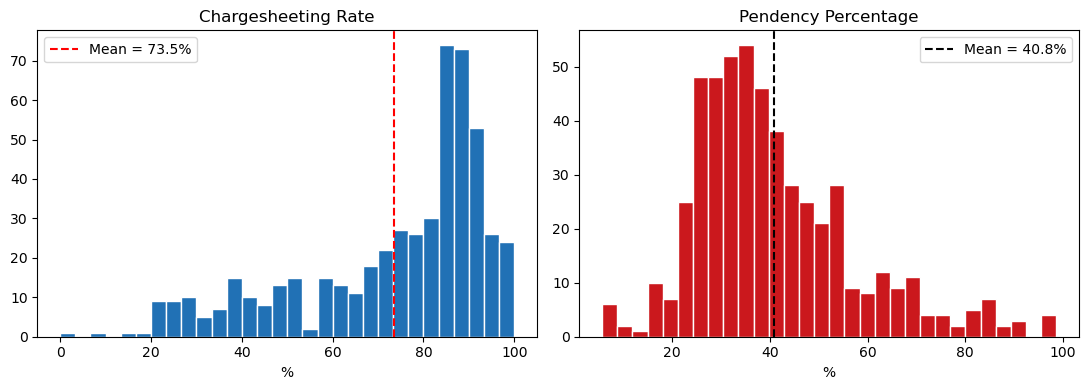

In [62]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

#chargesheeting rate plot
ax1.hist(df["chargesheeting_rate"], bins=30, color="#2171B5", edgecolor="white")
ax1.axvline(df["chargesheeting_rate"].mean(),
            color="red",
            linestyle="--",
            label=f"Mean = {df['chargesheeting_rate'].mean():.1f}%")
ax1.set_title("Chargesheeting Rate")
ax1.set_xlabel("%")
ax1.legend()

#pendency percentage plot
ax2.hist(df["pendency_pct"], bins=30, color="#CB181D", edgecolor="white")
ax2.axvline(df["pendency_pct"].mean(),
            color="black", 
            linestyle="--",
            label=f"Mean = {df['pendency_pct'].mean():.1f}%")
ax2.set_title("Pendency Percentage")
ax2.set_xlabel("%")
ax2.legend()

plt.tight_layout()
plt.savefig("eda_1_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

**Observation**: 
* `Chargesheeting Rate` is varied from 0-100 but can be seen to be right skewed. Most values lie in a limited range.
* `Pendency Percent` is spread out more as compared to the chargesheeting rate, indicating a lot of dependency on the type of crime.

### EDA 2 — COVID dip: how 2020 affected the pipeline

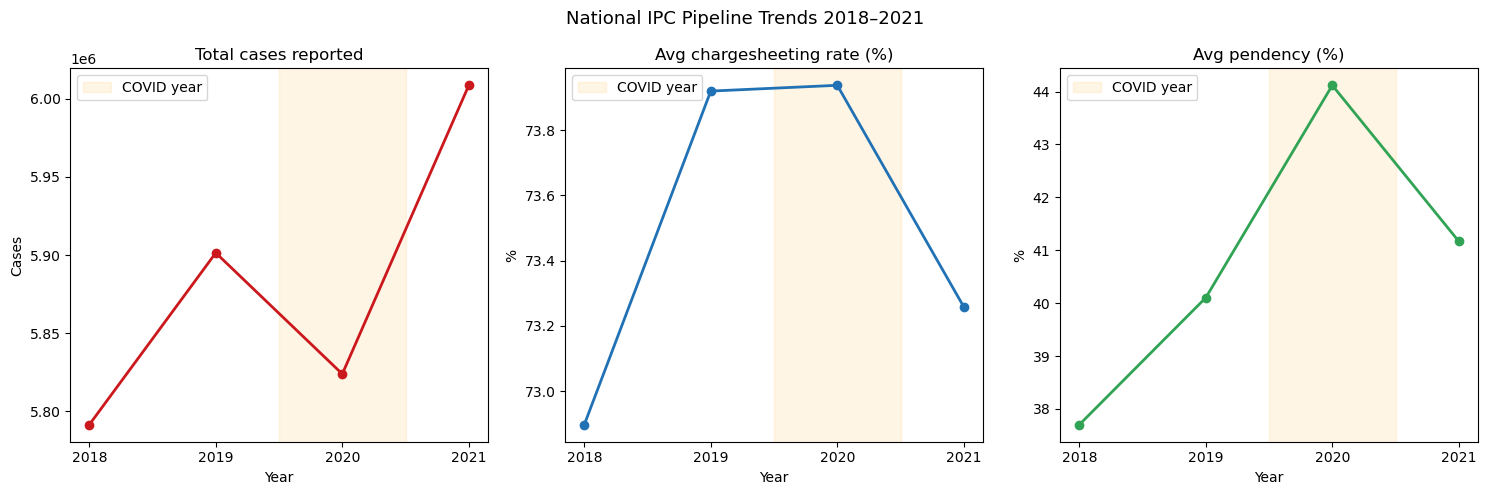

In [63]:
# Aggregate by year
yearly = df.groupby("year").agg(
    total_reported = ("cases_reported", "sum"),
    avg_cs_rate    = ("chargesheeting_rate", "mean"),
    avg_pendency   = ("pendency_pct", "mean")
).reset_index()


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
 
# Plot 1 — total cases reported
ax1.plot(yearly["year"], yearly["total_reported"], marker="o", color="#CB181D", linewidth=2)
ax1.axvspan(2019.5, 2020.5, alpha=0.1, color="orange", label="COVID year")
ax1.set_title("Total cases reported")
ax1.set_xlabel("Year")
ax1.set_ylabel("Cases")
ax1.set_xticks([2018, 2019, 2020, 2021])
ax1.legend()
 
# Plot 2 — average chargesheeting rate
ax2.plot(yearly["year"], yearly["avg_cs_rate"], marker="o", color="#2171B5", linewidth=2)
ax2.axvspan(2019.5, 2020.5, alpha=0.1, color="orange", label="COVID year")
ax2.set_title("Avg chargesheeting rate (%)")
ax2.set_xlabel("Year")
ax2.set_ylabel("%")
ax2.set_xticks([2018, 2019, 2020, 2021])
ax2.legend()
 
# Plot 3 — average pendency
ax3.plot(yearly["year"], yearly["avg_pendency"], marker="o", color="#31A354", linewidth=2)
ax3.axvspan(2019.5, 2020.5, alpha=0.1, color="orange", label="COVID year")
ax3.set_title("Avg pendency (%)")
ax3.set_xlabel("Year")
ax3.set_ylabel("%")
ax3.set_xticks([2018, 2019, 2020, 2021])
ax3.legend()
 
plt.suptitle("National IPC Pipeline Trends 2018–2021", fontsize=13)
plt.tight_layout()
plt.savefig("eda_2_covid_dip.png", dpi=150, bbox_inches="tight")
plt.show()

### EDA 3 — Which features correlate with the target?
Before we start modelling, we must check if there are any features closely correlated with the target. Any feature having correlation > 0.85 must be excluded.

In [64]:
corr_features = [
    "log_cases_reported",
    "log_total_for_inv",
    "pendency_load",
    "reopened_rate",
    "transferred_rate",
    "fr_rate",
    "fr_false_rate",
    "fr_insufficient_rate",
    "cs_carryover_rate",
    "severity_ordinal",
    "chargesheeting_rate",
    "pendency_pct",
]

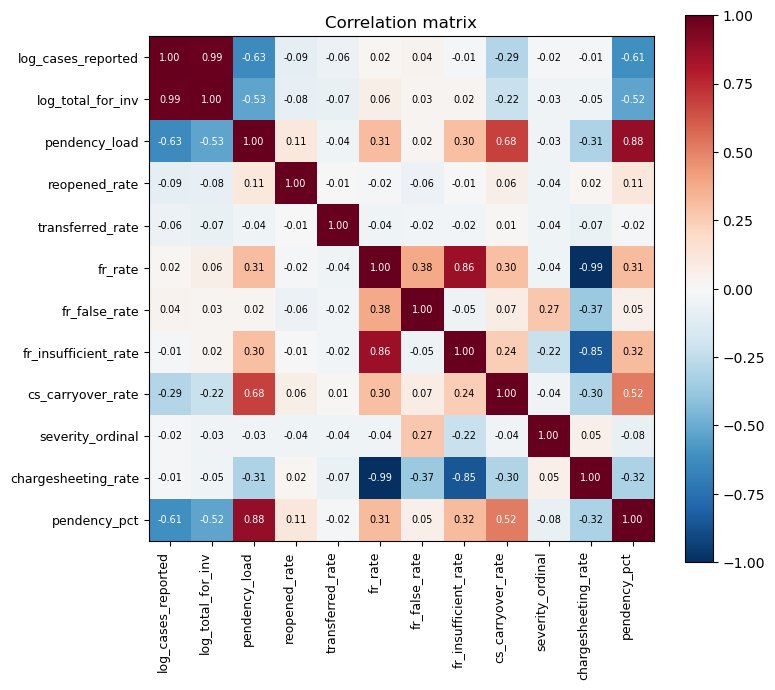


Correlations with chargesheeting_rate:
fr_rate                -0.994
fr_insufficient_rate   -0.853
fr_false_rate          -0.372
pendency_pct           -0.319
pendency_load          -0.307
cs_carryover_rate      -0.301
transferred_rate       -0.068
log_total_for_inv      -0.046
log_cases_reported     -0.010
reopened_rate           0.019
severity_ordinal        0.049
chargesheeting_rate     1.000
Name: chargesheeting_rate, dtype: float64


In [65]:
corr = df[corr_features].corr()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr_features)))
ax.set_yticks(range(len(corr_features)))
ax.set_xticklabels(corr_features, rotation=90 ,ha="right", fontsize=9)
ax.set_yticklabels(corr_features, fontsize=9)

for i in range(len(corr_features)):
    for j in range(len(corr_features)):
        val = corr.values[i, j]
        color = "white" if abs(val) > 0.5 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7, color=color)

ax.set_title("Correlation matrix")
plt.tight_layout()
plt.savefig("eda_3_correlation.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nCorrelations with chargesheeting_rate:")
print(df[corr_features].corr()["chargesheeting_rate"].sort_values().round(3))

**Observation**: `fr_rate`, `fr_insufficient_rate` has high correlation with chargesheeting_rate, hence we need to drop these features before we begin modelling as they might leak the information to rebuild the target.

# Phase 3 ML modelling

In [66]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [67]:
# Leakage-free feature set
base_features = [
    "log_cases_reported",
    "log_total_for_inv",
    "pendency_load",
    "severity_ordinal",
    "year_feature",
]

In [68]:
# Add the category one-hot columns (they start with "cat_")
cat_cols = []
for col in df.columns:
    if col.startswith("cat_"):
        cat_cols.append(col)

features = base_features + cat_cols
targets  = ["chargesheeting_rate", "pendency_pct"]
years = [2019, 2020, 2021]

df = df.dropna(subset=features + targets).copy()

print("Rows left:", len(df))
print("Number features:", len(features))

Rows left: 519
Number features: 11


### Baseline Models

**Baseline 1 - Global Mean**
* For each year, predict the average value for all crimes. This is quite frankly a very dump model. It is clearly not useful, but just for a point of reference.

**Baseline 2 - Per Crime Mean**
* For each crime, predict the historical average. This is actually much smarter approach, as each crime behaves in its own consistent way.

In [69]:
#store baseline and results of all models
all_results = []

In [70]:
#Calculating baseline
for target in targets:
    print(f"\nTarget: {target}")
    
    # Baseline 1 - Global Mean
    true_vals  = []
    pred_vals  = []
    
    for year in years:
    
        train = df[df["year"] < year]
        test  = df[df["year"] == year]
    
        mean_value = train[target].mean()
    
        for val in test[target]:
            true_vals.append(val)
            pred_vals.append(mean_value)
    
    b1_rmse = np.sqrt(mean_squared_error(true_vals, pred_vals))
    b1_mae  = mean_absolute_error(true_vals, pred_vals)
    
    print(f"Baseline 1 (global mean): RMSE={b1_rmse:.2f}, MAE={b1_mae:.2f}")
    all_results.append({
        "model": "Baseline 1 (global mean) :", 
        "target": target,
        "rmse": b1_rmse,
        "mae": b1_mae
    })

for target in targets:
    print(f"\nTarget: {target}")
    # Baseline 2: Per Crime Mean
    true_vals  = []
    pred_vals  = []
    
    for year in years:
    
        train = df[df["year"] < year]
        test  = df[df["year"] == year]
    
        crime_means = train.groupby("crime_head_norm")[target].mean()
        overall_mean = train[target].mean()
    
        for i in range(len(test)):
            crime = test.iloc[i]["crime_head_norm"]
    
            if crime in crime_means:
                pred = crime_means[crime]
            else:
                pred = overall_mean
    
            pred_vals.append(pred)
            true_vals.append(test.iloc[i][target])
    
    b2_rmse = np.sqrt(mean_squared_error(true_vals, pred_vals))
    b2_mae  = mean_absolute_error(true_vals, pred_vals)
    
    print(f"Baseline 2 (per-crime mean): RMSE={b2_rmse:.2f}, MAE={b2_mae:.2f}")

    all_results.append({
        "model": "Baseline 2 (per-crime mean): ",
        "target": target,
        "rmse": b2_rmse,
        "mae": b2_mae
    })


Target: chargesheeting_rate
Baseline 1 (global mean): RMSE=21.32, MAE=17.38

Target: pendency_pct
Baseline 1 (global mean): RMSE=16.89, MAE=12.56

Target: chargesheeting_rate
Baseline 2 (per-crime mean): RMSE=8.74, MAE=4.51

Target: pendency_pct
Baseline 2 (per-crime mean): RMSE=8.52, MAE=5.43


### Model Training

This is a time-based data, so if we do random split, it would use future data to predict the past, which would introduce data leakage. We want to avoid that. Hence, we do time-based validation, i.e., Train on past years and test on future years.

Example:
* Train: 2018-19 -> Test: 2020
* Train: 2018-20 -> Test: 2021

In [71]:
def time_series_cv(model, target, scale=False):
    rmse_list = []
    mae_list  = []

    for test_year in years:
        # to handle future leakage
        train = df[df["year"] < test_year]
        test  = df[df["year"] == test_year]

        X_train = train[features]
        y_train = train[target]
        X_test  = test[features]
        y_test  = test[target]

        #Scaling if needed
        if scale:
            scaler = StandardScaler()
            X_train  = scaler.fit_transform(X_train)
            X_test   = scaler.transform(X_test)

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae  = mean_absolute_error(y_test, y_pred)
        
        rmse_list.append(rmse)
        mae_list.append(mae)

    avg_rmse = np.mean(rmse_list)
    avg_mae  = np.mean(mae_list)
    
    return avg_rmse, avg_mae

In [72]:
 #Linear Regression
for target in targets:
    print(f"\nLinear Regression - Target: {target}")

    model = LinearRegression()
    rmse, mae = time_series_cv(model, target, scale=True)
    print(f"Linear: RMSE={rmse:.2f}, MAE={mae:.2f}")

    all_results.append({"model": "Linear", "target": target, "rmse": rmse, "mae": mae})


Linear Regression - Target: chargesheeting_rate
Linear: RMSE=17.72, MAE=13.63

Linear Regression - Target: pendency_pct
Linear: RMSE=8.36, MAE=5.61


In [73]:
#Ridge
alphas = [0.01, 0.1, 1, 10]

for target in targets:
    print(f"\nRidge - Target: {target}")

    best_rmse = float('inf')
    best_mae = None
    best_alpha = None

    for alpha in alphas:
        model = Ridge(alpha=alpha)
        rmse, mae = time_series_cv(model, target, scale=True)

        print(f"Ridge: alpha={alpha} -> RMSE={rmse:.2f}, MAE={mae:.2f}")

        if rmse < best_rmse:
            best_rmse = rmse
            best_mae = mae
            best_alpha = alpha

    print(f"Best Parameter for Ridge: alpha={best_alpha} -> RMSE={best_rmse:.2f}, MAE={best_mae:.2f}")

    all_results.append({
        "model": "Ridge",
        "target": target,
        "rmse":best_rmse,
        "mae": best_mae
    })


Ridge - Target: chargesheeting_rate
Ridge: alpha=0.01 -> RMSE=17.72, MAE=13.62
Ridge: alpha=0.1 -> RMSE=17.72, MAE=13.64
Ridge: alpha=1 -> RMSE=17.84, MAE=13.83
Ridge: alpha=10 -> RMSE=18.09, MAE=14.10
Best Parameter for Ridge: alpha=0.01 -> RMSE=17.72, MAE=13.62

Ridge - Target: pendency_pct
Ridge: alpha=0.01 -> RMSE=8.36, MAE=5.61
Ridge: alpha=0.1 -> RMSE=8.35, MAE=5.61
Ridge: alpha=1 -> RMSE=8.33, MAE=5.60
Ridge: alpha=10 -> RMSE=8.31, MAE=5.59
Best Parameter for Ridge: alpha=10 -> RMSE=8.31, MAE=5.59


In [74]:
#Lasso
alphas = [0.01, 0.1, 1]

for target in targets:
    print(f"\nLasso - Target: {target}")

    best_rmse = float('inf')
    best_mae = None
    best_alpha = None

    for alpha in alphas:
        model = Lasso(alpha=alpha, max_iter=1500)
        rmse, mae = time_series_cv(model, target, scale=True)

        print(f"Lasso: alpha={alpha} -> RMSE={rmse:.2f}, MAE={mae:.2f}")

        if rmse < best_rmse:
            best_rmse = rmse
            best_mae = mae
            best_alpha = alpha

    print(f"Best Parameter for Lasso: alpha={best_alpha} -> RMSE={best_rmse:.2f}, MAE={best_mae:.2f}")

    all_results.append({
        "model": "Lasso",
        "target": target,
        "rmse":best_rmse,
        "mae": best_mae
    })


Lasso - Target: chargesheeting_rate
Lasso: alpha=0.01 -> RMSE=17.72, MAE=13.63
Lasso: alpha=0.1 -> RMSE=17.94, MAE=14.01
Lasso: alpha=1 -> RMSE=18.46, MAE=14.94
Best Parameter for Lasso: alpha=0.01 -> RMSE=17.72, MAE=13.63

Lasso - Target: pendency_pct
Lasso: alpha=0.01 -> RMSE=8.34, MAE=5.60
Lasso: alpha=0.1 -> RMSE=8.29, MAE=5.55
Lasso: alpha=1 -> RMSE=8.03, MAE=5.33
Best Parameter for Lasso: alpha=1 -> RMSE=8.03, MAE=5.33


In [75]:
#Random Forest
n_list = [100, 200]
depth_list = [5, 10, None]

for target in targets:
    print(f"\nRandom Forest - Target: {target}")
    
    best_rmse = float('inf')
    best_mae = None
    best_params = None

    for n in n_list:
        for d in depth_list:
            model = RandomForestRegressor(
                n_estimators=n,
                max_depth=d,
                random_state=9
            )

            rmse, mae = time_series_cv(model, target)

            print(f"RF: n={n}, depth={d} -> RMSE={rmse:.2f}, MAE={mae:.2f}")

            if rmse < best_rmse:
                best_rmse = rmse
                best_mae = mae
                best_params = f"n={n}, depth={d}"

    print(f"Best Parameter for RF: {best_params} -> RMSE={best_rmse:.2f}, MAE={best_mae:.2f}")

    all_results.append({
        "model": "Random Forest",
        "target": target,
        "rmse": best_rmse,
        "mae": best_mae
    })


Random Forest - Target: chargesheeting_rate
RF: n=100, depth=5 -> RMSE=15.75, MAE=11.45
RF: n=100, depth=10 -> RMSE=15.35, MAE=10.33
RF: n=100, depth=None -> RMSE=15.33, MAE=10.27
RF: n=200, depth=5 -> RMSE=15.67, MAE=11.38
RF: n=200, depth=10 -> RMSE=15.25, MAE=10.31
RF: n=200, depth=None -> RMSE=15.21, MAE=10.22
Best Parameter for RF: n=200, depth=None -> RMSE=15.21, MAE=10.22

Random Forest - Target: pendency_pct
RF: n=100, depth=5 -> RMSE=8.14, MAE=5.36
RF: n=100, depth=10 -> RMSE=8.34, MAE=5.61
RF: n=100, depth=None -> RMSE=8.39, MAE=5.63
RF: n=200, depth=5 -> RMSE=8.13, MAE=5.35
RF: n=200, depth=10 -> RMSE=8.36, MAE=5.60
RF: n=200, depth=None -> RMSE=8.39, MAE=5.62
Best Parameter for RF: n=200, depth=5 -> RMSE=8.13, MAE=5.35


In [76]:
#SVR
C_vals = [0.1, 1]
eps_vals = [0.1, 0.5, 1]

for target in targets:
    print(f"\nSVR - Target: {target}")

    best_rmse = float('inf')
    best_mae = None
    best_params = None

    for C in C_vals:
        for eps in eps_vals:
            model = SVR(C=C, epsilon=eps)

            rmse, mae = time_series_cv(model, target)

            print(f"SVR: C={C}, eps={eps} -> RMSE={rmse:.2f}, MAE={mae:.2f}")

            if rmse < best_rmse:
                best_rmse = rmse
                best_mae = mae
                best_params = f"C={C}, eps={eps}"

    print(f"Best Parameter for SVR: {best_params} -> RMSE={best_rmse:.2f}, MAE={best_mae:.2f}")

    all_results.append({
        "model": "SVR",
        "target": target,
        "rmse": best_rmse,
        "mae": best_mae
    })


SVR - Target: chargesheeting_rate
SVR: C=0.1, eps=0.1 -> RMSE=22.69, MAE=15.94
SVR: C=0.1, eps=0.5 -> RMSE=22.70, MAE=15.94
SVR: C=0.1, eps=1 -> RMSE=22.69, MAE=15.94
SVR: C=1, eps=0.1 -> RMSE=22.66, MAE=15.77
SVR: C=1, eps=0.5 -> RMSE=22.66, MAE=15.77
SVR: C=1, eps=1 -> RMSE=22.66, MAE=15.77
Best Parameter for SVR: C=1, eps=0.5 -> RMSE=22.66, MAE=15.77

SVR - Target: pendency_pct
SVR: C=0.1, eps=0.1 -> RMSE=16.95, MAE=12.19
SVR: C=0.1, eps=0.5 -> RMSE=16.93, MAE=12.18
SVR: C=0.1, eps=1 -> RMSE=16.94, MAE=12.18
SVR: C=1, eps=0.1 -> RMSE=15.10, MAE=11.00
SVR: C=1, eps=0.5 -> RMSE=15.03, MAE=10.97
SVR: C=1, eps=1 -> RMSE=15.01, MAE=10.97
Best Parameter for SVR: C=1, eps=1 -> RMSE=15.01, MAE=10.97


In [77]:
#Gradient Boosting
n_list = [100, 200]
learning_rates = [0.01, 0.05, 0.1]

for target in targets:
    print(f"\nGradient Boosting - Target: {target}")

    best_rmse = float('inf')
    best_mae = None
    best_params = None

    for n in n_list:
        for lr in learning_rates:
            model = GradientBoostingRegressor(
                n_estimators=n,
                learning_rate=lr,
                random_state=9
            )

            rmse, mae = time_series_cv(model, target)

            print(f"Gradient Boosting: n={n}, lr={lr} -> RMSE={rmse:.2f}, MAE={mae:.2f}")

            if rmse < best_rmse:
                best_rmse = rmse
                best_mae = mae
                best_params = f"n={n}, lr={lr}"

    print(f"Best Parameter for Gradient Boosting: {best_params} -> RMSE={best_rmse:.2f}, MAE={best_mae:.2f}")

    all_results.append({
        "model": "Gradient Boosting",
        "target": target,
        "rmse": best_rmse,
        "mae": best_mae
    })


Gradient Boosting - Target: chargesheeting_rate
Gradient Boosting: n=100, lr=0.01 -> RMSE=17.24, MAE=13.68
Gradient Boosting: n=100, lr=0.05 -> RMSE=15.80, MAE=11.23
Gradient Boosting: n=100, lr=0.1 -> RMSE=16.06, MAE=10.70
Gradient Boosting: n=200, lr=0.01 -> RMSE=16.40, MAE=12.40
Gradient Boosting: n=200, lr=0.05 -> RMSE=15.88, MAE=10.71
Gradient Boosting: n=200, lr=0.1 -> RMSE=16.48, MAE=10.63
Best Parameter for Gradient Boosting: n=100, lr=0.05 -> RMSE=15.80, MAE=11.23

Gradient Boosting - Target: pendency_pct
Gradient Boosting: n=100, lr=0.01 -> RMSE=9.38, MAE=6.96
Gradient Boosting: n=100, lr=0.05 -> RMSE=8.31, MAE=5.50
Gradient Boosting: n=100, lr=0.1 -> RMSE=8.67, MAE=5.67
Gradient Boosting: n=200, lr=0.01 -> RMSE=8.07, MAE=5.68
Gradient Boosting: n=200, lr=0.05 -> RMSE=8.62, MAE=5.66
Gradient Boosting: n=200, lr=0.1 -> RMSE=8.85, MAE=5.78
Best Parameter for Gradient Boosting: n=200, lr=0.01 -> RMSE=8.07, MAE=5.68


In [78]:
results_df = pd.DataFrame(all_results)
results_df

,model,target,rmse,mae
0,Baseline 1 (global mean) :,chargesheeting_rate,21.317750,17.379495
1,Baseline 1 (global mean) :,pendency_pct,16.893055,12.564373
2,Baseline 2 (per-crime mean):,chargesheeting_rate,8.743313,4.510469
3,Baseline 2 (per-crime mean):,pendency_pct,8.520467,5.427428
4,Linear,chargesheeting_rate,17.721332,13.625278
5,Linear,pendency_pct,8.355543,5.614625
6,Ridge,chargesheeting_rate,17.720940,13.624500
7,Ridge,pendency_pct,8.307316,5.590775
8,Lasso,chargesheeting_rate,17.724112,13.633069
9,Lasso,pendency_pct,8.025698,5.333115


In [79]:
print("RMSE Summary Table")
table = results_df.pivot(index="model", columns="target", values="rmse").round(2)
print(table.to_string())

RMSE Summary Table
target                         chargesheeting_rate  pendency_pct
model                                                           
Baseline 1 (global mean) :                   21.32         16.89
Baseline 2 (per-crime mean):                  8.74          8.52
Gradient Boosting                            15.80          8.07
Lasso                                        17.72          8.03
Linear                                       17.72          8.36
Random Forest                                15.21          8.13
Ridge                                        17.72          8.31
SVR                                          22.66         15.01


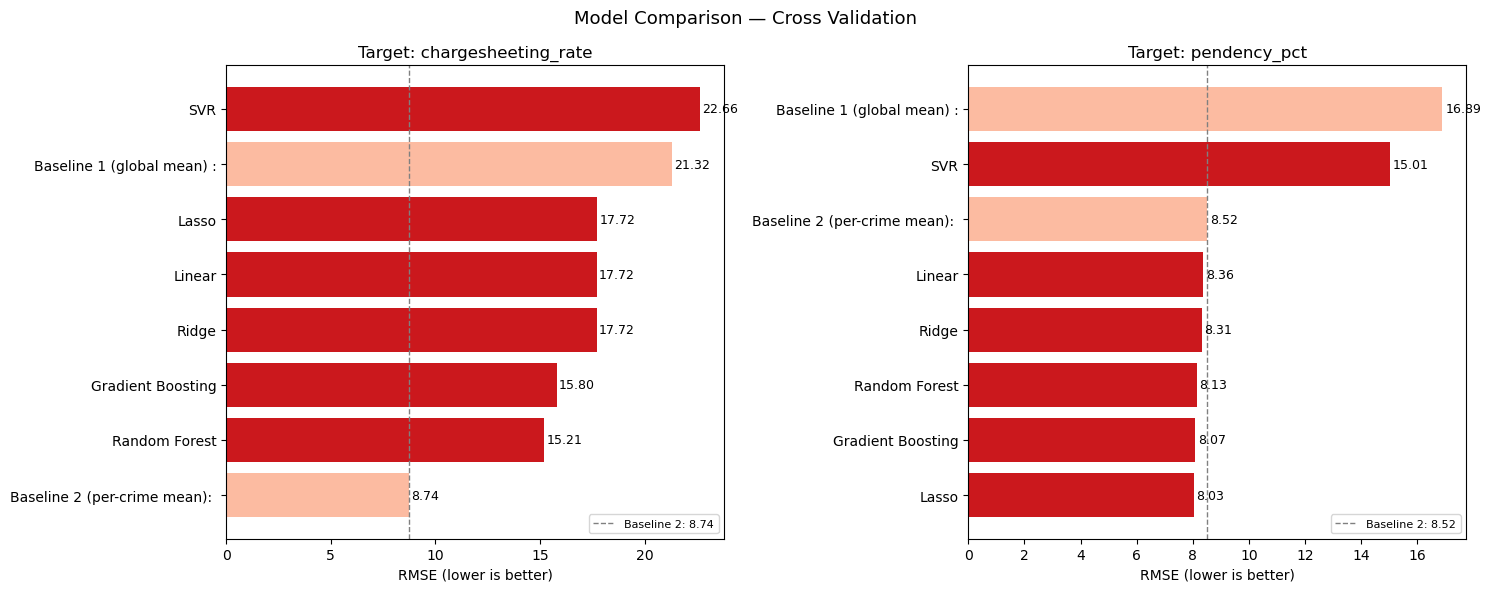

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, target in zip(axes, results_df["target"].unique()):
    subset = results_df[results_df["target"] == target].sort_values("rmse")

    colors = [
        "#FCBBA1" if "Baseline" in m else "#CB181D"
        for m in subset["model"]
    ]

    ax.barh(subset["model"], subset["rmse"], color=colors)

    # labels
    for i, val in enumerate(subset["rmse"]):
        ax.text(val + 0.1, i, f"{val:.2f}", va="center", fontsize=9)

    # baseline reference (if exists)
    b2 = subset[subset["model"].str.contains("per-crime", case=False)]
    if not b2.empty:
        b2_val = b2["rmse"].values[0]
        ax.axvline(b2_val, color="gray", linestyle="--", linewidth=1,
                   label=f"Baseline 2: {b2_val:.2f}")

    ax.set_xlabel("RMSE (lower is better)")
    ax.set_title(f"Target: {target}")
    ax.legend(fontsize=8)

plt.suptitle("Model Comparison — Cross Validation", fontsize=13)
plt.tight_layout()
plt.show()

**Observation**: The *per-crime mean* baseline is really strong (RMSE being 8.74). No ML model comes close to this baseline which essentially tells us that the crime-type identity alone can explain most if not all of the year-to-year signals.

In [81]:
trained_models = {}

# chargesheeting_rate model
rf_cs = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42
)
rf_cs.fit(df[features], df["chargesheeting_rate"])

trained_models[("Random Forest", "chargesheeting_rate")] = rf_cs


# pendency_pct model
rf_pen = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)
rf_pen.fit(df[features], df["pendency_pct"])

trained_models[("Random Forest", "pendency_pct")] = rf_pen

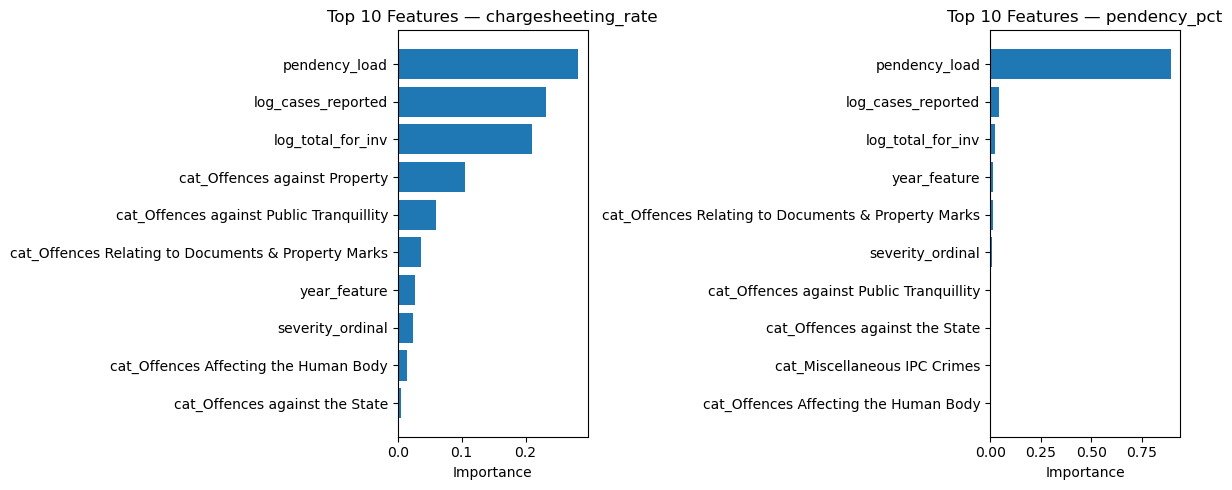

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, target in zip(axes, ["chargesheeting_rate", "pendency_pct"]):
    rf = trained_models[("Random Forest", target)]

    imp = pd.Series(
        rf.feature_importances_,
        index=features
    ).sort_values(ascending=True).tail(10)

    ax.barh(imp.index, imp.values)
    ax.set_title(f"Top 10 Features — {target}")
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

**Observation**
* The per-crime baseline is extremely stable, especially for chargesheeting rate, reasoning is that year-to-year variation is very small and there is little to nothing for ML models to learn new signal from.

* ML failed to best the baseline, this is because the crime type already captures the variation and the dataset is limited to only **4** years, this provides a very small temporal depth, hence the model has nothing complex to learn beyond averages.

# Phase 5 Clustering

If crimes behave similarly, naturally they should group together.

**Question**
* Do crime types group into distinct 'behaviour profiles' based on their pipeline signature?

In [83]:
profile_cols = ["log_cases_reported", "pendency_load", "fr_rate",
                "chargesheeting_rate", "pendency_pct"]

crime_profile = (df.groupby("crime_head_norm")[profile_cols]
                   .mean().dropna().reset_index())

X_cluster = StandardScaler().fit_transform(crime_profile[profile_cols])
print("Crime profile table:", crime_profile.shape)
crime_profile.head()

Crime profile table: (125, 6)


,crime_head_norm,log_cases_reported,pendency_load,fr_rate,chargesheeting_rate,pendency_pct
0,abetment of suicide,9.070452,0.363936,0.139920,85.825,40.250
1,acid attack,5.326039,0.350283,0.170994,82.900,34.700
2,affray,8.788914,0.207252,0.006226,99.375,23.225
3,agrarian,7.480046,0.458815,0.116365,88.350,42.875
4,arson,9.022907,0.459419,0.410407,58.925,44.000


In [84]:
ks = list(range(2, 9))

#Choosing K using 2 diagnostics:
# 1) Silhouette Score - Peak indicate best-separated clusters
# 2) Inerita - "elbow" finding
sils, inertias = [], []

for k in ks:
    km = KMeans(n_clusters=k, random_state=9, n_init=10).fit(X_cluster)
    sils.append(silhouette_score(X_cluster, km.labels_))
    inertias.append(km.inertias_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ks, kmeans_sil, marker="o", label="K-Means")
ax.plot(ks, hier_sil,   marker="s", label="Hierarchical (Ward)")
ax.set_xlabel("k"); ax.set_ylabel("Silhouette"); ax.grid(alpha=0.3); ax.legend()
ax.set_title("Choosing k")
plt.tight_layout()
plt.savefig("cluster_silhouette.png", dpi=120, bbox_inches="tight")
plt.show()

print("K-Means      :", [f"{s:.3f}" for s in kmeans_sil])
print("Hierarchical :", [f"{s:.3f}" for s in hier_sil])


NameError: name 'KMeans' is not defined

In [ ]:
# Choose K using two diagnostics:
#   (1) Silhouette score — peak indicates best-separated clusters
#   (2) Inertia (within-cluster sum of squares) — look for the "elbow"
import warnings
warnings.filterwarnings("ignore")

ks = list(range(2, 9))
sils, inertias = [], []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_cluster)
    sils.append(silhouette_score(X_cluster, km.labels_))
    inertias.append(km.inertia_)

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(ks, sils, marker="o", linewidth=2)
ax1.set_xlabel("k (number of clusters)")
ax1.set_ylabel("Silhouette score")
ax1.grid(True, alpha=0.3)
best_k = ks[int(np.argmax(sils))]
ax1.axvline(best_k, color="red", linestyle="--", alpha=0.5, label=f"peak at k={best_k}")
ax1.legend()

ax2.plot(ks, inertias, marker="s",color="red", linewidth=2)
ax2.set_xlabel("k (number of clusters)")
ax2.set_ylabel("Inertia")
ax2.grid(True, alpha=0.3)

plt.suptitle("K-Means: choosing k", fontsize=12)
plt.tight_layout()
plt.savefig("cluster_k_selection.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
# K-Means with K=3 
km_final = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_cluster)
crime_profile["cluster"] = km_final.labels_

# Cluster summary
summary = crime_profile.groupby("cluster")[profile_cols].mean().round(2)
summary["count"] = crime_profile.groupby("cluster").size()
print("Cluster centroids: ")
print(summary.to_string())

print("\nExample crimes in each cluster")
for c in sorted(crime_profile["cluster"].unique()):
    sample = crime_profile[crime_profile["cluster"] == c]["crime_head_norm"].head(10).tolist()
    print(f"\nCluster {c} ({summary.loc[c, 'count']} crimes):")
    for s in sample:
        print(f"   * {s}")

**Observation**:
Crimes do tend to form distinct behavioural profiles based on how they move around the police investigation pipeline, indicative that some crimes are processed more efficiently, some are difficult to solve, etc.

The clustering results align with expectations, violent crimes tend have a higher priority assigned, hence resolved more efficiently, whereas financial crimes exhibit higher level of complexity and low chargesheeting rates.